<img src="logoucm.png" style="height: 200px">
<center style="color:#888"><br/></center>


<font size="6"><center style="color:#1B4F72"><br/>
Técnicas de Simulación</center></font>
<font size="4"><center style="color:#1B4F72"><br/>
Máster en Ingeniería Matemática</center></font>

<font size="5"><center><span style="color:#117864">***Nombre y Apellidos: Ana Marta Oliveira dos Santos, Mario Queipo Silva y Siria Catherine Iniguez Brito***</span></center></font>

<font size="5"><center><span style="color:#1B4F72">***Práctica 9: Cadenas de Markov — Sistema de Atención al Cliente***</span></center></font>

### Objetivo
Modelar el proceso de atención al cliente en una empresa mediante una cadena de Markov en tiempo discreto (DTMC), analizar su evolución temporal, identificar estados absorbentes y calcular métricas clave mediante la teoría de matrices y mediante simulación.

### Importamos las librerías necesarias

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats

## 1. Descripción del Modelo

Un cliente puede encontrarse en uno de los siguientes estados:

| Estado | Descripción |
|--------|-------------|
| 0 | Primer contacto |
| 1 | Esperando respuesta |
| 2 | Siendo atendido |
| 3 | Problema resuelto (**absorbente**) |
| 4 | Se da de baja (**absorbente**) |

Los estados 3 y 4 son **absorbentes**: una vez que el cliente llega a ellos, no puede salir. Los estados 0, 1 y 2 son **transitorios**.

## 2. Definición de la Cadena de Markov

In [2]:
states = ['Contacto', 'Esperando', 'Atendido', 'Resuelto', 'Baja']
n_states = len(states)

# Matriz de transición P[i,j] = P(ir al estado j | estar en estado i)
P = np.array([
    [0.10, 0.60, 0.20, 0.05, 0.05],  # Desde Contacto
    [0.00, 0.30, 0.60, 0.05, 0.05],  # Desde Esperando
    [0.00, 0.10, 0.40, 0.40, 0.10],  # Desde Atendido
    [0.00, 0.00, 0.00, 1.00, 0.00],  # Desde Resuelto (absorbente)
    [0.00, 0.00, 0.00, 0.00, 1.00],  # Desde Baja (absorbente)
])

# Distribución inicial: el cliente comienza siempre en "Primer contacto"
pi0 = np.array([1, 0, 0, 0, 0], dtype=float)

# Verificamos que cada fila suma 1
print("Verificación de filas (deben sumar 1):")
print(P.sum(axis=1))

# Mostramos la matriz de transición
df_P = pd.DataFrame(P, index=states, columns=states)
print("\nMatriz de transición P:")
print(df_P.to_string())

Verificación de filas (deben sumar 1):
[1. 1. 1. 1. 1.]

Matriz de transición P:
           Contacto  Esperando  Atendido  Resuelto  Baja
Contacto        0.1        0.6       0.2      0.05  0.05
Esperando       0.0        0.3       0.6      0.05  0.05
Atendido        0.0        0.1       0.4      0.40  0.10
Resuelto        0.0        0.0       0.0      1.00  0.00
Baja            0.0        0.0       0.0      0.00  1.00


## 3. Evolución Temporal de la Distribución de Probabilidad

La distribución de probabilidad en el instante $n$ se obtiene como:
$$\pi^{(n)} = \pi^{(0)} \cdot P^n$$

Calcula y representa gráficamente la evolución de $\pi^{(n)}$ para $n = 0, 1, \ldots, 30$.

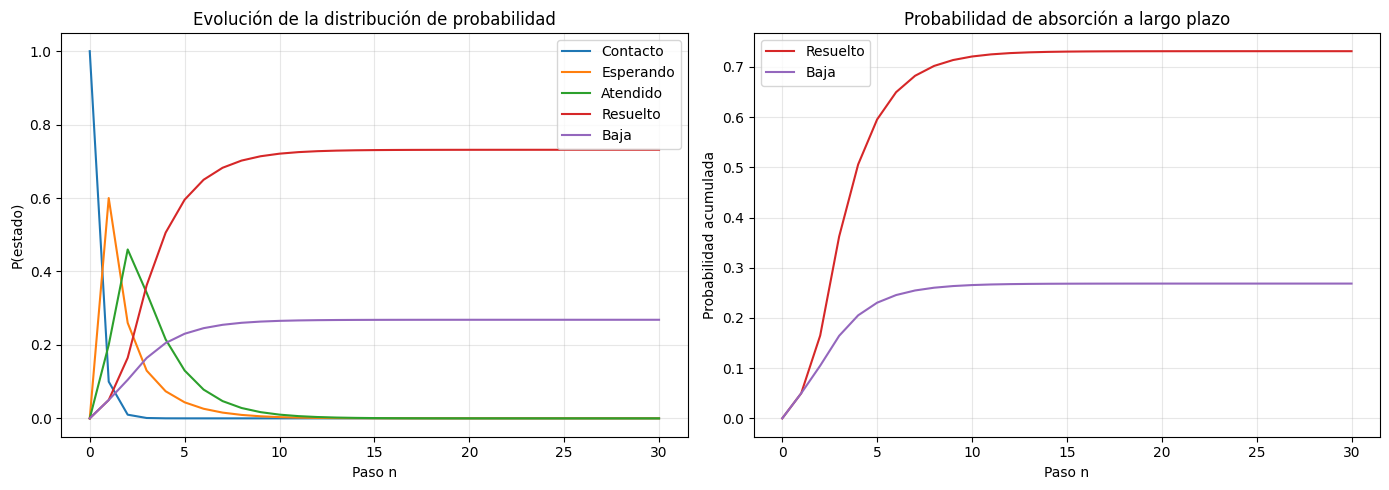


Distribución límite (n=30):
  P(Contacto) = 0.000000
  P(Esperando) = 0.000000
  P(Atendido) = 0.000000
  P(Resuelto) = 0.731481
  P(Baja) = 0.268518


In [3]:
n_pasos = 30
evolucion = np.zeros((n_pasos + 1, n_states))
evolucion[0] = pi0

for n in range(1, n_pasos + 1):
    evolucion[n] = evolucion[n - 1] @ P

# Representación gráfica
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Todos los estados
colores = ['C0', 'C1', 'C2', 'C3', 'C4']
for i, (estado, color) in enumerate(zip(states, colores)):
    axes[0].plot(range(n_pasos + 1), evolucion[:, i], label=estado, color=color)
axes[0].set_title("Evolución de la distribución de probabilidad")
axes[0].set_xlabel("Paso n")
axes[0].set_ylabel("P(estado)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Solo estados absorbentes (más claro para ver la convergencia)
axes[1].plot(range(n_pasos + 1), evolucion[:, 3], label='Resuelto', color='C3')
axes[1].plot(range(n_pasos + 1), evolucion[:, 4], label='Baja', color='C4')
axes[1].set_title("Probabilidad de absorción a largo plazo")
axes[1].set_xlabel("Paso n")
axes[1].set_ylabel("Probabilidad acumulada")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nDistribución límite (n={n_pasos}):")
for estado, prob in zip(states, evolucion[-1]):
    print(f"  P({estado}) = {prob:.6f}")

## 4. Análisis Teórico: Matriz Fundamental

Para cadenas con estados absorbentes, organizamos la matriz de transición en bloques:
$$P = \begin{pmatrix} Q & R \\ 0 & I \end{pmatrix}$$

donde $Q$ es la submatriz de transición entre estados **transitorios** y $R$ es la submatriz de transición de estados **transitorios** a **absorbentes**.

La **matriz fundamental** $N = (I - Q)^{-1}$ recoge el número esperado de visitas a cada estado transitorio antes de la absorción:
- $N_{ij}$ = número esperado de veces que se visita el estado transitorio $j$ partiendo del estado $i$.
- **Tiempo esperado hasta la absorción** desde el estado $i$: $t_i = \sum_j N_{ij}$.
- **Probabilidades de absorción**: $B = N \cdot R$, donde $B_{ij}$ es la probabilidad de ser absorbido en el estado $j$ partiendo del estado $i$.

In [4]:
# Estados transitorios (0, 1, 2) y absorbentes (3, 4)
idx_trans = [0, 1, 2]
idx_abs   = [3, 4]
estados_trans = [states[i] for i in idx_trans]
estados_abs   = [states[i] for i in idx_abs]

# Submatrices Q y R
Q = P[np.ix_(idx_trans, idx_trans)]
R = P[np.ix_(idx_trans, idx_abs)]

print("Submatriz Q (transitorios → transitorios):")
print(pd.DataFrame(Q, index=estados_trans, columns=estados_trans).to_string())

print("\nSubmatriz R (transitorios → absorbentes):")
print(pd.DataFrame(R, index=estados_trans, columns=estados_abs).to_string())

# Matriz fundamental N = (I - Q)^{-1}
I = np.eye(len(idx_trans))
N = np.linalg.inv(I - Q)

print("\nMatriz fundamental N = (I-Q)^{-1}:")
print(pd.DataFrame(N, index=estados_trans, columns=estados_trans).round(4).to_string())

# Tiempo esperado hasta la absorción
t_absorcion = N.sum(axis=1)
print("\nTiempo esperado hasta la absorción:")
for estado, t in zip(estados_trans, t_absorcion):
    print(f"  Desde '{estado}': {t:.4f} pasos")

# Probabilidades de absorción
B = N @ R
print("\nProbabilidades de absorción B = N·R:")
df_B = pd.DataFrame(B, index=estados_trans, columns=estados_abs)
print(df_B.round(4).to_string())

Submatriz Q (transitorios → transitorios):
           Contacto  Esperando  Atendido
Contacto        0.1        0.6       0.2
Esperando       0.0        0.3       0.6
Atendido        0.0        0.1       0.4

Submatriz R (transitorios → absorbentes):
           Resuelto  Baja
Contacto       0.05  0.05
Esperando      0.05  0.05
Atendido       0.40  0.10

Matriz fundamental N = (I-Q)^{-1}:
           Contacto  Esperando  Atendido
Contacto     1.1111     1.1728    1.5432
Esperando    0.0000     1.6667    1.6667
Atendido     0.0000     0.2778    1.9444

Tiempo esperado hasta la absorción:
  Desde 'Contacto': 3.8272 pasos
  Desde 'Esperando': 3.3333 pasos
  Desde 'Atendido': 2.2222 pasos

Probabilidades de absorción B = N·R:
           Resuelto    Baja
Contacto     0.7315  0.2685
Esperando    0.7500  0.2500
Atendido     0.7917  0.2083


## 5. Simulación Monte Carlo

Simula $n_{\text{sim}}$ trayectorias de la cadena partiendo del estado inicial y compara los resultados empíricos con los teóricos.

In [5]:
def simula_trayectoria(P, estado_inicial, estados_abs, max_pasos=1000):
    """Simula una trayectoria de la DTMC hasta llegar a un estado absorbente.
    Devuelve (estado_absorbente, número_de_pasos)."""
    estado = estado_inicial
    pasos = 0
    while estado not in estados_abs and pasos < max_pasos:
        estado = np.random.choice(len(P), p=P[estado])
        pasos += 1
    return estado, pasos

np.random.seed(42)
n_sim = 10000

# Simulamos partiendo de cada estado transitorio
resultados = {}
for i, estado_nombre in zip(idx_trans, estados_trans):
    abs_estados = []
    tiempos = []
    for _ in range(n_sim):
        est_abs, t = simula_trayectoria(P, i, idx_abs)
        abs_estados.append(est_abs)
        tiempos.append(t)
    resultados[estado_nombre] = {
        'abs_estados': abs_estados,
        'tiempos': tiempos
    }

# Comparación empírico vs teórico
print("Comparación empírica vs teórica")
print("="*65)
for i, estado_nombre in zip(idx_trans, estados_trans):
    abs_estados = resultados[estado_nombre]['abs_estados']
    tiempos = resultados[estado_nombre]['tiempos']

    prob_resuelto_emp = np.mean([e == 3 for e in abs_estados])
    prob_baja_emp     = np.mean([e == 4 for e in abs_estados])
    tiempo_emp        = np.mean(tiempos)

    idx_i = idx_trans.index(i)
    print(f"\nDesde '{estado_nombre}':")
    print(f"  P(Resuelto) — empírica: {prob_resuelto_emp:.4f} | teórica: {B[idx_i, 0]:.4f}")
    print(f"  P(Baja)     — empírica: {prob_baja_emp:.4f} | teórica: {B[idx_i, 1]:.4f}")
    print(f"  Tiempo medio — empírico: {tiempo_emp:.4f} | teórico: {t_absorcion[idx_i]:.4f}")

Comparación empírica vs teórica

Desde 'Contacto':
  P(Resuelto) — empírica: 0.7338 | teórica: 0.7315
  P(Baja)     — empírica: 0.2662 | teórica: 0.2685
  Tiempo medio — empírico: 3.8324 | teórico: 3.8272

Desde 'Esperando':
  P(Resuelto) — empírica: 0.7604 | teórica: 0.7500
  P(Baja)     — empírica: 0.2396 | teórica: 0.2500
  Tiempo medio — empírico: 3.3340 | teórico: 3.3333

Desde 'Atendido':
  P(Resuelto) — empírica: 0.7971 | teórica: 0.7917
  P(Baja)     — empírica: 0.2029 | teórica: 0.2083
  Tiempo medio — empírico: 2.2061 | teórico: 2.2222


## 6. Cuestiones

Responde a las siguientes preguntas utilizando los resultados obtenidos en las secciones anteriores:

1. ¿Qué estado absorbente tiene mayor probabilidad de alcanzarse partiendo del estado inicial "Primer contacto"? ¿Y desde "Atendido"?

2. ¿Cuál es el tiempo esperado hasta la absorción desde el estado "Esperando respuesta"? ¿Y desde "Atendido"?

3. ¿Los resultados empíricos de la simulación coinciden con los teóricos? ¿Con cuántas simulaciones se consigue una aproximación razonable?

4. Interpreta el significado de cada entrada de la matriz fundamental $N$. ¿Qué nos dice $N_{01}$?

5. ¿Qué cambios en la matriz de transición $P$ reducirían la probabilidad de abandono (estado "Baja")? Modifica la matriz y recalcula las probabilidades de absorción para verificarlo.

6. ¿Qué estrategias de negocio sugieren los valores obtenidos? ¿En qué estado es más urgente intervenir?

## 6.1. Respuestas a las Cuestiones

### 1. ¿Qué estado absorbente tiene mayor probabilidad de alcanzarse partiendo del estado inicial "Primer contacto"? ¿Y desde "Atendido"?

En ambos casos, el estado absorbente con mayor probabilidad de alcanzarse es **"Problema resuelto"**.

**Justificación Teórica:** A partir del cálculo de la matriz de probabilidades de absorción $B = N \cdot R$, observamos que:
* Partiendo de **"Contacto"**, la probabilidad de llegar a "Resuelto" es de 0.7315, muy superior al 0.2685 de terminar en "Baja".
* Partiendo de **"Atendido"**, esta probabilidad de éxito aumenta a 0.7917, reduciéndose la probabilidad de "Baja" a 0.2083.


*Análisis:* Este incremento probabilístico tiene sentido en la dinámica del sistema: a medida que el cliente avanza en el flujo de atención y llega a ser atendido, el riesgo de que abandone ("Baja") disminuye, aumentando la tasa de éxito ("Resuelto").

**Justificación Empírica:** La simulación de Monte Carlo (10.000 trayectorias) corrobora directamente estos valores analíticos. Se registraron tasas empíricas de resolución de 0.7338 (desde "Contacto") y 0.7971 (desde "Atendido"), demostrando la convergencia práctica del modelo estocástico.

### 2. ¿Cuál es el tiempo esperado hasta la absorción desde el estado "Esperando respuesta"? ¿Y desde "Atendido"?

El tiempo esperado hasta que el cliente sale del sistema (llega a un estado absorbente) es de **3.33 pasos** si parte de "Esperando respuesta", y de **2.22 pasos** si parte de "Atendido".

**Justificación Teórica:** El tiempo esperado hasta la absorción se obtiene sumando los elementos de cada fila de la matriz fundamental $N = (I-Q)^{-1}$, utilizando la expresión $t_i = \sum_j N_{ij}$.
* Desde **"Esperando"**, la suma de las visitas esperadas a los distintos estados transitorios es $0.0000 + 1.6667 + 1.6667 = 3.3334$ pasos.
* Desde **"Atendido"**, la suma correspondiente es $0.0000 + 0.2778 + 1.9444 = 2.2222$ pasos.
Analíticamente, esto refleja que el cliente requerirá menos transiciones para salir del sistema cuanto más avanzado se encuentre en el proceso de atención.

**Justificación Empírica:** La simulación de Monte Carlo (10.000 iteraciones) ratifica esta métrica. Los tiempos medios obtenidos de forma empírica son 3.3340 pasos desde "Esperando" y 2.2061 pasos desde "Atendido", valores que convergen casi de forma exacta con el modelo teórico.


### 3. ¿Los resultados empíricos de la simulación coinciden con los teóricos? ¿Con cuántas simulaciones se consigue una aproximación razonable?

Sí, los resultados empíricos coinciden bastante con los teóricos. Tomando como referencia el inicio en "Contacto", la probabilidad teórica de llegar a "Resuelto" es 0.7315 y el tiempo medio es 3.8272 pasos. Con la simulación de 10.000 iteraciones, se obtuvieron valores empíricos de 0.7338 y 3.8324, con diferencias de apenas unas milésimas.

Para determinar formalmente a partir de cuántas simulaciones se considera una "aproximación razonable" (donde el error se estabiliza), es necesario realizar un análisis de sensibilidad sobre el tamaño muestral.

In [6]:
# Datos del modelo
P = np.array([
    [0.10, 0.60, 0.20, 0.05, 0.05],
    [0.00, 0.30, 0.60, 0.05, 0.05],
    [0.00, 0.10, 0.40, 0.40, 0.10],
    [0.00, 0.00, 0.00, 1.00, 0.00],
    [0.00, 0.00, 0.00, 0.00, 1.00]
])
idx_abs = [3, 4]

# Valores teóricos calculados desde "Contacto" (estado 0)
teorico_prob_resuelto = 0.7315
teorico_tiempo = 3.8272

# Bucle para diferentes valores de N
ns_sim = [100, 500, 1000, 5000, 10000, 50000]
resultados = []

np.random.seed(42) # Fijamos la semilla para reproducibilidad

for n in ns_sim:
    np.random.seed(42)
    abs_estados = []
    tiempos = []
    for _ in range(n):
        est, t = simula_trayectoria(P, 0, idx_abs)
        abs_estados.append(est)
        tiempos.append(t)

    emp_prob = np.mean([e == 3 for e in abs_estados])
    emp_tiempo = np.mean(tiempos)
    error_prob = abs(emp_prob - teorico_prob_resuelto)
    error_tiempo = abs(emp_tiempo - teorico_tiempo)

    resultados.append({
        "Simulaciones (N)": n,
        "P(Resuelto) Emp.": round(emp_prob, 4),
        "Error Prob": round(error_prob, 4),
        "Tiempo Emp.": round(emp_tiempo, 4),
        "Error Tiempo": round(error_tiempo, 4)
    })

# Mostrar resultados en formato tabla
df_resultados = pd.DataFrame(resultados)
print("ANÁLISIS DE CONVERGENCIA MONTE CARLO:\n")
print(df_resultados.to_string(index=False))

ANÁLISIS DE CONVERGENCIA MONTE CARLO:

 Simulaciones (N)  P(Resuelto) Emp.  Error Prob  Tiempo Emp.  Error Tiempo
              100            0.7500      0.0185       3.8200        0.0072
              500            0.7240      0.0075       3.8140        0.0132
             1000            0.7290      0.0025       3.8540        0.0268
             5000            0.7336      0.0021       3.8434        0.0162
            10000            0.7338      0.0023       3.8324        0.0052
            50000            0.7348      0.0033       3.8195        0.0077


**Análisis de la Aproximación Razonable:**

Analizando los resultados de la tabla generada, podemos observar de forma empírica el efecto de la Ley de los Grandes Números:

* **Para valores bajos (N = 100):** La varianza estocástica es mayor, mostrando el error en probabilidad más alto de la serie (0.0185).
* **En la franja intermedia (N = 500 a N = 5000):** El error en probabilidad se reduce rápidamente por debajo de 0.01, estabilizándose en torno a 0.002. Sin embargo, el error en el tiempo empírico sigue sufriendo ciertas fluctuaciones aleatorias (subiendo a 0.0268 en N = 1000 y a 0.0162 en N = 5000).
* **Estabilización (N = 10000 en adelante):** Al alcanzar las 10.000 iteraciones, ambos errores caen a umbrales muy bajos (0.0023 para la probabilidad y 0.0052 para el tiempo). Aumentar a 50.000 iteraciones no aporta una mejora sustancial, ya que los errores se mantienen en el mismo orden de magnitud.

**Conclusión:** En este modelo de Markov, se puede considerar que una **aproximación razonable** comienza a partir de las **5.000 simulaciones**, donde la probabilidad ya es muy fiable. No obstante, las **10.000 simulaciones** ejecutadas en el código base representan el tamaño muestral óptimo, garantizando que el error de ambas métricas (probabilidad y tiempo) se minimiza y estabiliza sólidamente en el segundo y tercer decimal, sin un coste computacional innecesario.



### 4. Interpreta el significado de cada entrada de la matriz fundamental $N$. ¿Qué nos dice $N_{01}$?

En la teoría de Cadenas de Markov, cada entrada $N_{ij}$ de la matriz fundamental representa el número esperado de visitas (o el tiempo total en pasos) que el proceso realizará en el estado transitorio $j$, dado que partió inicialmente del estado transitorio $i$, antes de alcanzar la absorción.

$$\begin{array}{rccc}
 & \text{Contacto (0)} & \text{Esperando (1)} & \text{Atendido (2)} \\
\text{Contacto (0):} & 1.1111 & \mathbf{1.1728} & 1.5432 \\
\text{Esperando (1):} & 0.0000 & 1.6667 & 1.6667 \\
\text{Atendido (2):} & 0.0000 & 0.2778 & 1.9444
\end{array}$$

**Interpretación específica de $N_{01}$:** Considerando que en nuestro modelo el índice 0 corresponde a "Primer contacto" y el índice 1 a "Esperando respuesta", la entrada $N_{01}$ refleja la relación esperada entre estos dos estados. Su valor teórico calculado es **1.1728**.

En el contexto de la empresa, esto significa que un cliente que ingresa al sistema por "Primer contacto" pasará, en promedio, **1.17 veces** por la fase de "Esperando respuesta" a lo largo de todo el proceso de atención, antes de salir definitivamente del sistema (ya sea hacia "Problema resuelto" o "Baja").


### 5. ¿Qué cambios en la matriz de transición P reducirían la probabilidad de abandono (estado "Baja")? Modifica la matriz y recalcula las probabilidades para verificarlo.

Para reducir verdaderamente la probabilidad de abandono global partiendo del "Primer contacto", no basta simplemente con reducir las probabilidades directas hacia "Baja" (la última columna de la matriz P). Debemos tener en cuenta dos factores críticos: **la redistribución del peso** y **el efecto multiplicador de las visitas**.

**1. La redistribución del peso (El problema de la dilución):**
Si restamos un 0.05 a la probabilidad de ir a "Baja" desde cualquier estado, la fila debe seguir sumando 1. Por tanto, ese 0.05 debe sumarse a otro estado.
* Si le damos ese 0.05 a un estado con alta probabilidad de abandono futuro (por ejemplo, redirigimos al cliente a "Esperando", que sabemos que tiene una alta probabilidad de acabar en baja), nuestro esfuerzo de retención se diluye. Le hemos salvado ahora, pero es probable que caiga en el siguiente paso.
* Para maximizar la retención, la probabilidad restada a "Baja" debe transferirse al estado con menor probabilidad de abandono posible (idealmente, transformarlo en una resolución directa sumándolo a "Resuelto").

**2. El efecto multiplicador (Por qué intervenir en "Atendido" es más rentable):**
Nuestra intuición podría decirnos que tapar la fuga en el "Primer contacto" es lo mejor porque por ahí pasa el 100% de la gente. Sin embargo, la matriz fundamental N nos dice cuántas veces de media pasa un cliente por cada estado:
* $N_{00}$ (Contacto): **1.11** veces.
* $N_{01}$ (Esperando): **1.17** veces.
* $N_{02}$ (Atendido): **1.54** veces.

Debido al bucle de frustración entre "Atendido" y "Esperando", un cliente medio es "Atendido" 1.54 veces. Esto significa que cualquier mejora que hagamos en el estado "Atendido" (tercera fila) se multiplicará por 1.54. Tapar una fuga en una tubería por la que el agua pasa 1.5 veces ahorra más agua que taparla en una por la que pasa solo 1 vez. Modificar la tercera fila ("Atendido") es, con diferencia, la estrategia más efectiva.

In [7]:
# Definición de datos base
states = ['Contacto', 'Esperando', 'Atendido', 'Resuelto', 'Baja']
idx_trans = [0, 1, 2]
idx_abs = [3, 4]

# Matriz Original P
P_base = np.array([
    [0.10, 0.60, 0.20, 0.05, 0.05],
    [0.00, 0.30, 0.60, 0.05, 0.05],
    [0.00, 0.10, 0.40, 0.40, 0.10],
    [0.00, 0.00, 0.00, 1.00, 0.00],
    [0.00, 0.00, 0.00, 0.00, 1.00]
])

def calcular_prob_baja_desde_contacto(P):
    """Calcula la probabilidad teórica de terminar en 'Baja' empezando en 'Contacto'"""
    Q = P[np.ix_(idx_trans, idx_trans)]
    R = P[np.ix_(idx_trans, idx_abs)]
    N = np.linalg.inv(np.eye(len(idx_trans)) - Q)
    B = N @ R
    return B[0, 1] # Fila 0 (Contacto), Columna 1 de R (Baja)

prob_base = calcular_prob_baja_desde_contacto(P_base)
print(f"Probabilidad de Baja ORIGINAL (desde Contacto): {prob_base:.4f} ({prob_base*100:.2f}%)\n")
print("-" * 65)

# Evaluamos los 3 escenarios reduciendo la fuga en un 0.05 (y sumándolo a Resuelto)
nombres_estados = ['Primer Contacto (Fila 1)', 'Esperando (Fila 2)', 'Atendido (Fila 3)']

for i in range(3):
    # Hacemos una copia independiente de la matriz original
    P_mod = P_base.copy()

    # Restamos 0.05 a Baja (columna 4) y se lo sumamos a Resuelto (columna 3)
    P_mod[i, 4] -= 0.05
    P_mod[i, 3] += 0.05

    # Calculamos la nueva probabilidad de baja total
    nueva_prob = calcular_prob_baja_desde_contacto(P_mod)
    reduccion_absoluta = prob_base - nueva_prob

    print(f"Mejorando solo '{nombres_estados[i]}':")
    print(f" -> Nueva prob. de Baja Total: {nueva_prob:.4f} ({nueva_prob*100:.2f}%)")
    print(f" -> Impacto global (Reducción de abandonos): -{reduccion_absoluta:.4f}")
    print("-" * 65)

Probabilidad de Baja ORIGINAL (desde Contacto): 0.2685 (26.85%)

-----------------------------------------------------------------
Mejorando solo 'Primer Contacto (Fila 1)':
 -> Nueva prob. de Baja Total: 0.2130 (21.30%)
 -> Impacto global (Reducción de abandonos): -0.0556
-----------------------------------------------------------------
Mejorando solo 'Esperando (Fila 2)':
 -> Nueva prob. de Baja Total: 0.2099 (20.99%)
 -> Impacto global (Reducción de abandonos): -0.0586
-----------------------------------------------------------------
Mejorando solo 'Atendido (Fila 3)':
 -> Nueva prob. de Baja Total: 0.1914 (19.14%)
 -> Impacto global (Reducción de abandonos): -0.0772
-----------------------------------------------------------------


**Análisis de los Resultados de la Simulación:**

Al observar la salida del código, comprobamos matemáticamente el efecto multiplicador. Aunque en los tres escenarios aplicamos exactamente el mismo esfuerzo (reducir la fuga en un 0.05 y sumarlo a la resolución), el impacto final es muy distinto:

* Mejorar el **Primer Contacto** solo reduce el abandono global en **0.0556**.
* Mejorar la fase **Esperando** reduce el abandono global en **0.0586**.
* Sin embargo, aplicar esa misma mejora en el estado **Atendido** logra una reducción del **0.0772**.

Por tanto, los datos confirman la justificación teórica: intervenir en el estado "Atendido" es significativamente más eficiente.



### 6. ¿Qué estrategias de negocio sugieren los valores obtenidos? ¿En qué estado es más urgente intervenir?

**1. Estado más urgente para intervenir:**
Como demostró el análisis de sensibilidad previo (basado en el efecto multiplicador de la matriz fundamental), es crítico y matemáticamente más rentable intervenir urgentemente en el estado **"Atendido"**. Al pasar un cliente medio 1.54 veces por este estado debido al bucle de espera, cualquier pequeña reducción en su probabilidad de fracaso genera el mayor impacto global en la retención.

**2. Estrategias de negocio sugeridas:**
Los valores teóricos y empíricos revelan un "cuello de botella": el 10% de los clientes abandona directamente mientras un agente los atiende, y otro 10% es devuelto a la cola de espera, impulsando la tasa de abandono total (desde el inicio) a casi el 27%. Para corregir estas ineficiencias del sistema, se sugieren las siguientes estrategias:
* **Capacitación técnica e incentivos (Foco en "Atendido"):** Implementar protocolos de resolución al primer contacto (*First Contact Resolution*) empoderando a los agentes. El objetivo es darles capacidad real para solucionar problemas sin necesidad de escalar o devolver al usuario a la espera, rompiendo así el bucle de frustración.
* **Optimización del enrutamiento inicial (Foco en "Contacto"):** La matriz muestra que el 60% de los clientes entra directamente a la cola de espera nada más contactar. Rediseñar el *triage* inicial (mediante un mejor IVR o pre-clasificación) permitiría enviar a más clientes directamente al estado "Atendido" por el departamento adecuado, descongestionando el sistema desde el paso cero.

## 7. Cuestiones Extras

Responde a las siguientes preguntas extras utilizando los resultados obtenidos en las secciones anteriores:


1. ¿Puede un cliente ser absorbido en "Resuelto", y luego vovler a "Contacto"?

2. Si suponemos que el tiempo esperado hasta absorcion desde "Contacto" es 3.82 pasos. ¿Significa eso que la mayoria de clientes se absorben en 4 pasos?

3. Si simulamos 1000 trayectorias y obtenemos P(Resuelto)=0.63 desde Contacto, podemos afirmar con un 95 % de confianza que la probabilidad real está entre 0.6 y 0.66?

4. Si $N_{22}$ = 1.95 ¿Signiica que desde "Atendido" se espera visitar "Atendido" 1.95 veces antes de absorción?

5. Si cambiasemos $P_{12}$ de 0.6 a 0.9 y reducimos $P_{11}$ proporcionalmente ¿Cambia el tiempo esperado desde "Esperando" ?

6. Si la distribución inicial  fuera (0.5, 0.5, 0, 0), ¿el tiempo esperado hasta absorcion sería el promedio de los tiempos desde "Contacto" y desde "Esperando"?

7. Puede la simulacion dar probabilidad 0 de absorción en Baja ?

## 7.1. Respuestas a las Cuestiones



### 1. ¿Puede un cliente ser absorbido en "Resuelto", y luego volver a "Contacto"?

No, es imposible. Por definición teórica, "Resuelto" es un estado absorbente. Esto significa que la probabilidad de salir de este estado una vez que se entra es nula ($P_{3j} = 0$ para todo $j \neq 3$). En la matriz de transición, la fila de "Resuelto" es [0, 0, 0, 1, 0], lo que garantiza que el cliente se queda en ese estado para siempre.



In [8]:
# Respuesta a pregunta 1

idx_r = states.index('Resuelto')  # Estado 3
idx_c = states.index('Contacto')  # Estado 0

# Extraemos la fila de transiciones desde el estado "Resuelto"
fila_resuelto = P[idx_r]

print("ANÁLISIS DE TRANSICIÓN DESDE 'RESUELTO'")
print("="*65)
print(f"Probabilidades de transición desde 'Resuelto' (Fila {idx_r}):")
for estado, prob in zip(states, fila_resuelto):
    print(f" - Ir a '{estado}': {prob:.4f}")

print("-" * 65)
print(f"¿P(Ir a 'Contacto' | estar en 'Resuelto') es 0?: {fila_resuelto[idx_c] == 0.0}")
print(f"¿P(Permanecer en 'Resuelto' | estar en 'Resuelto') es 1?: {fila_resuelto[idx_r] == 1.0}")

ANÁLISIS DE TRANSICIÓN DESDE 'RESUELTO'
Probabilidades de transición desde 'Resuelto' (Fila 3):
 - Ir a 'Contacto': 0.0000
 - Ir a 'Esperando': 0.0000
 - Ir a 'Atendido': 0.0000
 - Ir a 'Resuelto': 1.0000
 - Ir a 'Baja': 0.0000
-----------------------------------------------------------------
¿P(Ir a 'Contacto' | estar en 'Resuelto') es 0?: True
¿P(Permanecer en 'Resuelto' | estar en 'Resuelto') es 1?: True


### 2. Si suponemos que el tiempo esperado hasta absorción desde "Contacto" es 3.82 pasos, ¿significa eso que la mayoría de clientes se absorben en 4 pasos?

No necesariamente. El valor teórico de $3.8272$ pasos representa la **esperanza matemática (la media aritmética)** del sistema, una métrica muy sensible a los valores extremos de la cola que no determina dónde se concentra el grueso de la población.

En este proceso estocástico, la distribución del tiempo presenta un marcado **sesgo a la derecha** (asimetría positiva). Esto significa que la gran mayoría de los clientes experimenta trayectorias cortas y se absorbe de manera muy temprana, mientras que solo una pequeña minoría queda atrapada en bucles transitorios largos (como el retorno entre los estados *Esperando* y *Atendido*). Esas pocas trayectorias largas generan una cola alta en la distribución que desplaza el promedio hacia arriba, elevando la media empírica de la simulación a $3.8324$ pasos.

Este fenómeno de asimetría se constata formalmente al analizar los datos numéricos obtenidos tras la ejecución del código:
* **La mediana empírica se sitúa en exactamente 3 pasos**, lo que demuestra que el $50\%$ central de los usuarios requiere 3 pasos o menos para finalizar el proceso. En los primeros pasos, las probabilidades exactas de absorción acumulada son del $9.78\%$ en el paso 1, $27.11\%$ en el paso 2 y alcanzan el **$52.56\%$ en el paso 3**.
* Además, el **$70.63\%$ de los clientes se absorbe en **4 pasos o menos** ($\le 4$)**, tras añadir el $18.07\%$ correspondiente al cuarto paso.

**Conclusión:** La mayoría de los clientes quedaría obsorbido **antes o al alcanzar el cuarto paso**, pero no junto en 4 pasos. El valor esperado de $3.8272$ pasos no refleja la duración del perfil de usuario típico, sino el resultado matemático de promediar el $70.63\%$ de casos rápidos con el $29.37\%$ de usuarios que sufren demoras.

In [9]:
# Respuesta a pregunta 2
# Ejecución de la simulación base original (10,000 trayectorias desde 'Contacto')
np.random.seed(42)
n_sim_base = 10000
idx_contacto = 0
abs_estados_c = []
tiempos_contacto_lista = []

for _ in range(n_sim_base):
    est_abs, t = simula_trayectoria(P, idx_contacto, idx_abs)
    abs_estados_c.append(est_abs)
    tiempos_contacto_lista.append(t)


tiempos_contacto = np.array(tiempos_contacto_lista)

# Cálculo de estadísticos descriptivos empíricos
media_empirica = np.mean(tiempos_contacto)
mediana_empirica = np.median(tiempos_contacto)

# Cálculo de frecuencias relativas y distribución acumulada paso a paso
pasos_unicos, conteos = np.unique(tiempos_contacto, return_counts=True)
proporciones = conteos / len(tiempos_contacto)
acumulado = np.cumsum(proporciones)

# Evaluación de umbrales críticos (Paso 4)
pct_menor_igual_4 = np.mean(tiempos_contacto <= 4) * 100
pct_mayor_4 = np.mean(tiempos_contacto > 4) * 100

# Salida de resultados
print("DISTRIBUCIÓN DEL TIEMPO HASTA LA ABSORCIÓN DESDE 'CONTACTO'")
print("=" * 65)
print(f"Media teórica del sistema:    {3.8272:.4f} pasos")
print(f"Media empírica muestral:      {media_empirica:.4f} pasos")
print(f"Mediana empírica muestral:    {mediana_empirica:.4f} pasos")
print("-" * 65)
print(f"{'Paso (n)':<12}{'Prob. Abs. Exacta':<22}{'Prob. Abs. Acumulada (<= n)':<22}")
print("-" * 65)
for paso, prop, ac in zip(pasos_unicos[:6], proporciones[:6], acumulado[:6]):
    print(f"{paso:<12}{prop:<22.4f}{ac:<22.4f}")
print("-" * 65)
print(f"Clientes absorbidos en 4 pasos o menos (<= 4): {pct_menor_igual_4:.2f}%")
print(f"Clientes que requieren más de 4 pasos (> 4):    {pct_mayor_4:.2f}%")
print("=" * 65)

DISTRIBUCIÓN DEL TIEMPO HASTA LA ABSORCIÓN DESDE 'CONTACTO'
Media teórica del sistema:    3.8272 pasos
Media empírica muestral:      3.8324 pasos
Mediana empírica muestral:    3.0000 pasos
-----------------------------------------------------------------
Paso (n)    Prob. Abs. Exacta     Prob. Abs. Acumulada (<= n)
-----------------------------------------------------------------
1           0.0978                0.0978                
2           0.1733                0.2711                
3           0.2545                0.5256                
4           0.1807                0.7063                
5           0.1161                0.8224                
6           0.0727                0.8951                
-----------------------------------------------------------------
Clientes absorbidos en 4 pasos o menos (<= 4): 70.63%
Clientes que requieren más de 4 pasos (> 4):    29.37%


### 3. Si simulamos 1000 trayectorias y obtenemos P(Resuelto)=0.63 desde "Contacto", ¿podemos afirmar con un 95% de confianza que la probabilidad real está entre 0.6 y 0.66?

Sí, es una afirmación correcta estadísticamente. Utilizando la fórmula del intervalo de confianza para una proporción: $IC = p \pm Z \sqrt{\frac{p(1-p)}{n}}$Donde $p = 0.63$, $n = 1000$, y $Z \approx 1.96$ (para un 95% de confianza). El margen de error resultante es aproximadamente $0.03$. Por lo tanto, el intervalo es $[0.60, 0.66]$.


In [10]:
# Respuesta a pregunta 3
p_hat = 0.63
n = 1000
confianza = 0.95

alfa = 1 - confianza
z = stats.norm.ppf(1 - alfa / 2)

# Error estándar de la proporción: SE = sqrt( (p_hat * (1 - p_hat)) / n )
se = np.sqrt((p_hat * (1 - p_hat)) / n)

# Margen de error
margen_error = z * se

# Límites del Intervalo de Confianza al 95%
limite_inferior = p_hat - margen_error
limite_superior = p_hat + margen_error

# --- Cálculo del nivel de confianza exacto para el intervalo [0.60, 0.66] ---
z_inf_propuesto = (0.60 - p_hat) / se
z_sup_propuesto = (0.66 - p_hat) / se

# Calculamos el área bajo la curva normal estándar entre ambos valores Z
nivel_confianza_propuesto = (stats.norm.cdf(z_sup_propuesto) - stats.norm.cdf(z_inf_propuesto)) * 100

# --- IMPRESIÓN FORMAL DE RESULTADOS (SALIDA POR PANTALLA) ---
print("ANÁLISIS DE INTERVALO DE CONFIANZA )")
print("=" * 65)
print(f"Proporción muestral (p_hat):            {p_hat:.4f}")
print(f"Tamaño de muestra (N):                  {n}")
print(f"Error estándar estimado (SE):           {se:.6f}")
print(f"Valor crítico z (para 95%):             {z:.4f}")
print(f"Margen de error (para 95%):             {margen_error:.4f} (aprox. {margen_error*100:.2f}%)")

print("\nIntervalo de Confianza del 95% obtenido:")
print("-" * 65)
print(f"  [{limite_inferior:.6f}, {limite_superior:.6f}]")

print("\nEvaluación del intervalo propuesto [0.60, 0.66]:")
print("-" * 65)
# El intervalo [0.60, 0.66] contiene al IC si su límite inferior es menor que el nuestro y el superior mayor
print(f"¿El intervalo [0.60, 0.66] contiene al IC del 95%?: {0.60 <= limite_inferior and 0.66 >= limite_superior}")
print(f"Nivel de confianza exacto para [0.60, 0.66]:       {nivel_confianza_propuesto:.2f}%")
print("=" * 65)

ANÁLISIS DE INTERVALO DE CONFIANZA )
Proporción muestral (p_hat):            0.6300
Tamaño de muestra (N):                  1000
Error estándar estimado (SE):           0.015268
Valor crítico z (para 95%):             1.9600
Margen de error (para 95%):             0.0299 (aprox. 2.99%)

Intervalo de Confianza del 95% obtenido:
-----------------------------------------------------------------
  [0.600076, 0.659924]

Evaluación del intervalo propuesto [0.60, 0.66]:
-----------------------------------------------------------------
¿El intervalo [0.60, 0.66] contiene al IC del 95%?: True
Nivel de confianza exacto para [0.60, 0.66]:       95.06%


### 4. Si $N_{22} = 1.95$, ¿significa que desde "Atendido" se espera visitar "Atendido" 1.95 veces antes de absorción?

Sí. La matriz fundamental $N = (I-Q)^{-1}$ recoge el número esperado de visitas a cada estado transitorio $j$ partiendo del estado $i$. En este caso, el índice 2 corresponde a "Atendido", por lo que $N_{22}$ indica que, si empezamos en "Atendido", el cliente estará en ese estado un promedio de 1.95 veces (incluyendo la visita inicial) antes de acabar en "Resuelto" o "Baja".




### 5. Si cambiásemos $P_{12}$ de 0.6 a 0.9 y reducimos $P_{11}$ proporcionalmente, ¿cambia el tiempo esperado desde "Esperando"?

Sí, cambiaría (y de hecho, se reduciría). $P_{11}$ representa la probabilidad de quedarse atascado en el estado "Esperando". Si reducimos $P_{11}$ (de 0.3 a 0.0) y aumentamos $P_{12}$ (la transición hacia "Atendido"), estamos acelerando el paso del cliente por la cadena. Al modificar la submatriz $Q$, los valores de la matriz fundamental $N$ cambian, disminuyendo el tiempo total esperado hasta la absorción.




In [11]:
# Respuesta a pregunta 5
Q_original = np.array([[0.1, 0.6, 0.2], [0.0, 0.3, 0.6], [0.0, 0.1, 0.4]])
# Modificación: P12 de 0.6 -> 0.9, P11 de 0.3 -> 0.0
Q_mod = np.array([[0.1, 0.6, 0.2], [0.0, 0.0, 0.9], [0.0, 0.1, 0.4]])
t_orig = np.linalg.inv(np.eye(3) - Q_original).sum(axis=1)
t_mod = np.linalg.inv(np.eye(3) - Q_mod).sum(axis=1)
print(f"Pregunta 5: Cambio en tiempo esperado desde 'Esperando': {t_orig[1]:.4f} -> {t_mod[1]:.4f}")

Pregunta 5: Cambio en tiempo esperado desde 'Esperando': 3.3333 -> 2.9412


### 6. Si la distribución inicial fuera (0.5, 0.5, 0, 0, 0), ¿el tiempo esperado hasta absorción sería el promedio de los tiempos desde "Contacto" y desde "Esperando"?


Sí. Por la propiedad de la linealidad de la esperanza matemática, el tiempo esperado total es la suma ponderada de los tiempos esperados desde cada estado inicial. Si el 50% de los clientes empieza en "Contacto" y el otro 50% en "Esperando", el tiempo esperado global de la cadena será exactamente: $0.5 \cdot t_{\text{Contacto}} + 0.5 \cdot t_{\text{Esperando}}$.  Esto se demuestra formalmente mediante la propiedad de linealidad de la esperanza matemática y el Teorema de la Probabilidad Total.

---

#### Demostración Teórica

Sea $T$ la variable aleatoria que define el **número de pasos hasta la absorción**, y sea $\pi^{(0)} = (\pi_0^{(0)}, \pi_1^{(0)}, \pi_2^{(0)}, \pi_3^{(0)}, \pi_4^{(0)})$ el vector de distribución inicial sobre los 5 estados del espacio de estados $S = \{0, 1, 2, 3, 4\}$.

La esperanza global del tiempo de absorción, denotada como $E_{\pi^{(0)}}[T]$, se obtiene condicionando el proceso según el estado inicial $X_0 = i$ mediante el teorema de la probabilidad total:

$$E_{\pi^{(0)}}[T] = \sum_{i=0}^{4} E[T \mid X_0 = i] \cdot P(X_0 = i)$$

Si definimos $t_i = E[T \mid X_0 = i]$ como el tiempo medio hasta la absorción partiendo desde el estado $i$, podemos expandir por completo la sumatoria para los 5 estados:

$$E_{\pi^{(0)}}[T] = \pi_0^{(0)} \cdot t_0 + \pi_1^{(0)} \cdot t_1 + \pi_2^{(0)} \cdot t_2 + \pi_3^{(0)} \cdot t_3 + \pi_4^{(0)} \cdot t_4$$

Donde los índices corresponden a:
* $0$: Contacto
* $1$: Esperando
* $2$: Atendido
* $3$: Resuelto (Absorbente $\rightarrow t_3 = 0$)
* $4$: Baja (Absorbente $\rightarrow t_4 = 0$)

Sustituyendo tanto las propiedades de los estados absorbentes ($t_3 = 0, t_4 = 0$) como los valores reales de tu distribución inicial del enunciado, $\pi^{(0)} = (0.5, \, 0.5, \, 0, \, 0, \, 0)$, obtenemos:

$$E_{\pi^{(0)}}[T] = 0.5 \cdot t_0 + 0.5 \cdot t_1 + 0 \cdot t_2 + 0 \cdot 0 + 0 \cdot 0$$

Simplificando los términos nulos, la ecuación se reduce a:

$$E_{\pi^{(0)}}[T] = 0.5 \cdot t_0 + 0.5 \cdot t_1 = \frac{t_0 + t_1}{2}$$

Al ponderar el desglose completo de los 5 estados, el tiempo esperado global es exactamente la media aritmética (el promedio) de los tiempos individuales de absorción de los dos primeros estados.


In [12]:
# Tiempos esperados individuales
t_transitorios = N.sum(axis=1)

t_0 = t_transitorios[0]
t_1 = t_transitorios[1]

# Aplicación directa de la fórmula Promedio
E_T_promedio = 0.5 * t_0 + 0.5 * t_1


pi_0_completo = np.array([0.5, 0.5, 0.0, 0.0, 0.0])

idx_trans = [0, 1, 2]
t_completo = np.zeros(len(states))
t_completo[idx_trans] = t_transitorios  # Rellena las posiciones 0, 1 y 2 de forma automática
E_T_matricial = np.dot(pi_0_completo, t_completo)

print(f"E[T] calculado como promedio directo: {E_T_promedio:.4f} pasos")
print(f"E[T] calculado mediante producto escalar completo: {E_T_matricial:.4f} pasos")

E[T] calculado como promedio directo: 3.5802 pasos
E[T] calculado mediante producto escalar completo: 3.5802 pasos


### 7. Análisis de la viabilidad de obtener una probabilidad empírica nula de absorción en el estado "Baja"

Técnicamente es posible, pero altamente improbable con un número grande de simulaciones. Desde una perspectiva formal, con un diseño experimental basado en $n = 10,000$ trayectorias, la obtención de un valor empírico nulo es un suceso virtualmente imposible debido al fenómeno de convergencia estocástica dictado por la Ley Fuerte de los Grandes Números.

---

#### Fundamentación Teórica y Análisis del Modelo

A partir del análisis analítico de la cadena (mediante el cálculo matricial de la probabilidad de absorción $B = N \cdot R$), se establece que la probabilidad exacta de transitar desde el estado 0 ("Contacto") hacia el estado absorbente 4 ("Baja") es:

$$P(\text{Baja} \mid \text{Contacto}) = 0.2685 \quad (26.85\%)$$

Para que la simulación de Monte Carlo devuelva una probabilidad empírica de cero absoluto, se requeriría que ninguna de las trayectorias independientes finalizara en dicho estado de abandono. Sabiendo que la probabilidad de que un cliente individual evite la baja (suceso complementario) es de $1 - 0.2685 = 0.7315$, la probabilidad matemática global de que este escenario ocurra de forma simultánea a lo largo de las $10,000$ iteraciones se expresa como:

$$P(\text{Cero Bajas en la Simulación}) = (1 - 0.2685)^{10,000} \approx 1.5492\times 10^{-1358}$$

Este resultado representa un valor numérico con más de 1,300 ceros decimales, lo que a efectos prácticos de la computación científica y la estadística aplicada se considera un evento imposible.

#### Confrontación y Convergencia de Resultados

El comportamiento asintótico del sistema garantiza que, al aumentar el tamaño muestral, la frecuencia relativa empírica converge hacia el valor teórico esperado. Este principio se constata al comparar las métricas obtenidas en el estudio:

* **Probabilidad Teórica ($B_{01}$):** $0.2685$
* **Probabilidad Empírica ($\hat{p}$):** $0.2662$

La proximidad entre ambos valores (con $2.662$ trayectorias finalizadas en "Baja" dentro de la simulación) valida la estabilidad del modelo computacional.

**Conclusión:** Se determina que la simulación nunca arrojará una probabilidad nula de absorción bajo condiciones estándar de $10.000$ iteraciones. La única ventana metodológica donde resultaría plausible observar un cero empírico sería reduciendo el diseño experimental a un número de simulaciones críticamente pequeño (por ejemplo, 2 o 3 trayectorias), escenario en el cual el azar a corto plazo y la alta varianza muestral sesgarían por completo la naturaleza real del proceso estocástico.